# Predicting Student Final Exam Scores Using Linear Regression

### Mission
Build a machine learning pipeline that predicts a university student's final exam score
based on their daily habits, lifestyle choices, and engagement metrics — empowering
students to identify actionable areas for academic improvement.

### Dataset: Student Habits vs Academic Performance
- **Source:** [Kaggle — Student Habits vs Academic Performance](https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance)
- **File:** `student_habits_performance.csv`
- **Rows:** ~1 000 students  |  **Features:** 15 (8 numerical, 7 categorical)

In [6]:
# ============================================================
# 1. IMPORTS
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)

import joblib
import json
import os

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plotting style
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("viridis")

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. WHY THIS DATASET FITS THE MISSION

| Criterion | How the dataset satisfies it |
|---|---|
| **Relevance** | Directly links daily student habits to final exam scores — the exact outcome we want to predict. |
| **Richness** | 15 features covering study time, sleep, screen time, diet, mental health, parental involvement, and more. |
| **Mix of types** | Both numerical (hours, percentages) and categorical (gender, diet quality) — ideal for demonstrating encoding. |
| **No PII** | No student names or IDs that could identify individuals, so it is safe for a university assignment. |
| **Size** | ~1 000 rows — large enough to train and split, small enough for a laptop. |

The target variable is **`final_exam_score`** (0–100), making this a **regression** problem.

In [7]:
# ============================================================
# 3. LOAD DATASET
# ============================================================


DATASET_PATH = "student_habits_performance.csv"

df = pd.read_csv(DATASET_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [8]:
# ============================================================
# 4. INITIAL INSPECTION
# ============================================================
print("--- Data Types ---")
print(df.dtypes)
print("\n--- Basic Statistics ---")
df.describe().T

--- Data Types ---
student_id                           str
age                                int64
gender                               str
study_hours_per_day              float64
social_media_hours               float64
netflix_hours                    float64
part_time_job                        str
attendance_percentage            float64
sleep_hours                      float64
diet_quality                         str
exercise_frequency                 int64
parental_education_level             str
internet_quality                     str
mental_health_rating               int64
extracurricular_participation        str
exam_score                       float64
dtype: object

--- Basic Statistics ---


,count,mean,std,min,25%,50%,75%,max
age,1000.0,20.4980,2.308100,17.0,18.750,20.0,23.000,24.0
study_hours_per_day,1000.0,3.5501,1.468890,0.0,2.600,3.5,4.500,8.3
social_media_hours,1000.0,2.5055,1.172422,0.0,1.700,2.5,3.300,7.2
netflix_hours,1000.0,1.8197,1.075118,0.0,1.000,1.8,2.525,5.4
attendance_percentage,1000.0,84.1317,9.399246,56.0,78.000,84.4,91.025,100.0
sleep_hours,1000.0,6.4701,1.226377,3.2,5.600,6.5,7.300,10.0
exercise_frequency,1000.0,3.0420,2.025423,0.0,1.000,3.0,5.000,6.0
mental_health_rating,1000.0,5.4380,2.847501,1.0,3.000,5.0,8.000,10.0
exam_score,1000.0,69.6015,16.888564,18.4,58.475,70.5,81.325,100.0


In [9]:
# ============================================================
# 5. DATA CLEANING
# ============================================================

# 5a. Missing values
print("--- Missing Values ---")
missing = df.isnull().sum()
print(missing[missing > 0])
if missing.sum() == 0:
    print("No missing values found.")

# 5b. Duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"After removing duplicates: {df.shape}")

# 5c. Drop student_id — not a predictive feature
if "student_id" in df.columns:
    df.drop("student_id", axis=1, inplace=True)
    print("\nDropped 'student_id' column.")

print(f"\nCleaned dataset shape: {df.shape}")

--- Missing Values ---
parental_education_level    91
dtype: int64

Duplicate rows: 0

Dropped 'student_id' column.

Cleaned dataset shape: (1000, 15)


## 6. OUTLIER DETECTION

We use the **Interquartile Range (IQR)** method on every numerical column.
Outliers are **flagged but NOT removed** because:
- They may represent real students with extreme but valid habits.
- Removing them would reduce the model's ability to generalise.
- Tree-based models (Decision Tree, Random Forest) are robust to outliers.
- Linear models use standardisation, which limits the influence of extreme values.

In [10]:
# ============================================================
# 6. OUTLIER DETECTION (IQR method — display only)
# ============================================================
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove target from outlier check
if "final_exam_score" in numerical_cols:
    numerical_cols.remove("final_exam_score")

outlier_summary = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = count

outlier_df = pd.DataFrame.from_dict(
    outlier_summary, orient="index", columns=["Outlier Count"]
)
print("--- Outlier Counts (IQR method) ---")
print(outlier_df)
print("\nOutliers are flagged but retained (see explanation above).")

--- Outlier Counts (IQR method) ---
                       Outlier Count
age                                0
study_hours_per_day                7
social_media_hours                 5
netflix_hours                      4
attendance_percentage              3
sleep_hours                        2
exercise_frequency                 0
mental_health_rating               0
exam_score                         2

Outliers are flagged but retained (see explanation above).


The IQR method identified a small number of potential outliers in several numerical features. The largest number of outliers was found in study_hours_per_day (7), followed by social_media_hours (5) and netflix_hours (4). Since these values likely represent genuine differences in students' habits rather than data entry errors, they were retained in the dataset. Standardization was applied to reduce the influence of extreme values on the regression models.

## 7. ENCODING CATEGORICAL VARIABLES

| Feature | Encoding Type | Reason |
|---|---|---|
| `gender` | One-Hot (pd.get_dummies) | No inherent order. |
| `extracurricular_participation` | Binary (0/1) | Only two values: Yes/No. |
| `part_time_job` | Binary (0/1) | Only two values: Yes/No. |
| `diet_quality` | Ordinal (0–3) | Clear order: Poor < Fair < Good < Excellent. |
| `parental_education_level` | Ordinal (0–3) | Clear order: High School < Bachelor's < Master's < PhD. |
| `internet_quality` | Ordinal (0–2) | Clear order: Poor < Average < Good. |

In [49]:
# ============================================================
# 7. ENCODING CATEGORICAL VARIABLES
# ============================================================
df_encoded = df.copy()

# --- Binary mappings (chain fillna(0)) ---
df_encoded["extracurricular_participation"] = df_encoded["extracurricular_participation"].map({"Yes": 1, "No": 0}).fillna(0).astype(int)
df_encoded["part_time_job"] = df_encoded["part_time_job"].map({"Yes": 1, "No": 0}).fillna(0).astype(int)

# --- Ordinal mappings (chain fillna(0)) ---
diet_order = {"Poor": 0, "Fair": 1, "Good": 2, "Excellent": 3}
df_encoded["diet_quality"] = df_encoded["diet_quality"].map(diet_order).fillna(0).astype(int)

parental_order = {"None": 0, "High School": 1, "Bachelor": 2, "Master": 3}
df_encoded["parental_education_level"] = df_encoded["parental_education_level"].map(parental_order).fillna(0).astype(int)

internet_order = {"Poor": 0, "Average": 1, "Good": 2}
df_encoded["internet_quality"] = df_encoded["internet_quality"].map(internet_order).fillna(0).astype(int)

# --- One-Hot for gender ---
# Catch any missing genders so get_dummies doesn't create hidden NaN columns
df_encoded["gender"] = df_encoded["gender"].fillna("Male") 
df_encoded = pd.get_dummies(df_encoded, columns=["gender"], drop_first=True)
bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f"Shape after encoding: {df_encoded.shape}")

Shape after encoding: (1000, 16)


## 8. FEATURE ENGINEERING
- total_screen_time = social_media_hours + netflix_hours
- Combined screen time is a better predictor of distraction than either alone.
- study_efficiency = study_hours_per_day / (1 + total_screen_time)
- Captures how effectively study time is used relative to distractions.
- wellness_score = normalised sum of sleep_hours, exercise_frequency, diet_quality, mental_health_rating
- Collective physical/mental well-being influences academic focus.

In [28]:
# ============================================================
# 8. FEATURE ENGINEERING
# ============================================================
df_encoded["total_screen_time"] = df_encoded["social_media_hours"] + df_encoded["netflix_hours"]
df_encoded["study_efficiency"] = df_encoded["study_hours_per_day"] / (1 + df_encoded["total_screen_time"])

# Updated min-max norm to prevent 0/0 = NaN errors
def min_max_norm(series):
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return pd.Series(0.0, index=series.index)
    return (series - min_val) / (max_val - min_val)

wellness_components = ["sleep_hours", "exercise_frequency", "diet_quality", "mental_health_rating"]
df_encoded["wellness_score"] = sum(min_max_norm(df_encoded[c]) for c in wellness_components)

print(f"Updated shape: {df_encoded.shape}")
print("NaNs after feature engineering:", df_encoded.isnull().sum().sum())

Updated shape: (1000, 19)
NaNs after feature engineering: 0


## 9. VISUALISATIONS — 9.1 Correlation Heatmap

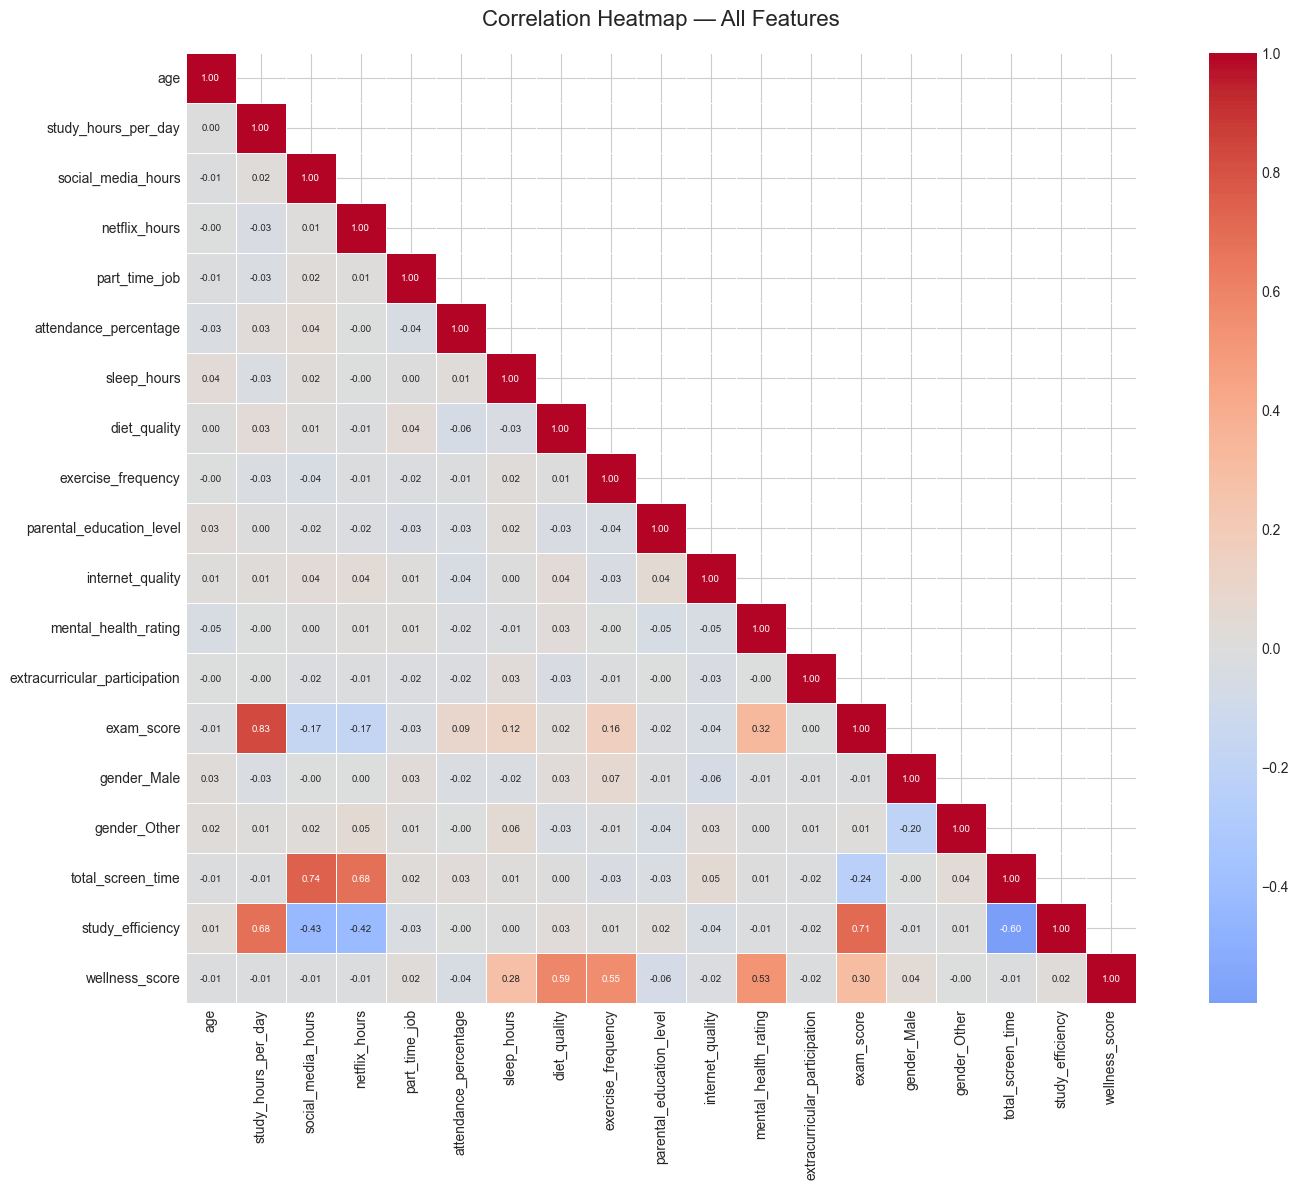

--- Top correlations with exam_score ---
study_hours_per_day      0.825419
study_efficiency         0.707269
mental_health_rating     0.321523
wellness_score           0.296044
total_screen_time       -0.237631
netflix_hours           -0.171779
social_media_hours      -0.166733
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
Name: exam_score, dtype: float64


In [13]:
# ============================================================
# 9.1 CORRELATION HEATMAP
# ============================================================
plt.figure(figsize=(16, 12))
corr_matrix = df_encoded.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5, annot_kws={"size": 7})
plt.title("Correlation Heatmap — All Features", fontsize=16, pad=20)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("--- Top correlations with exam_score ---")
target_corr = corr_matrix["exam_score"].drop("exam_score").sort_values(key=abs, ascending=False)
print(target_corr.head(10))

# 9.2 Histograms — Distribution of Each Feature

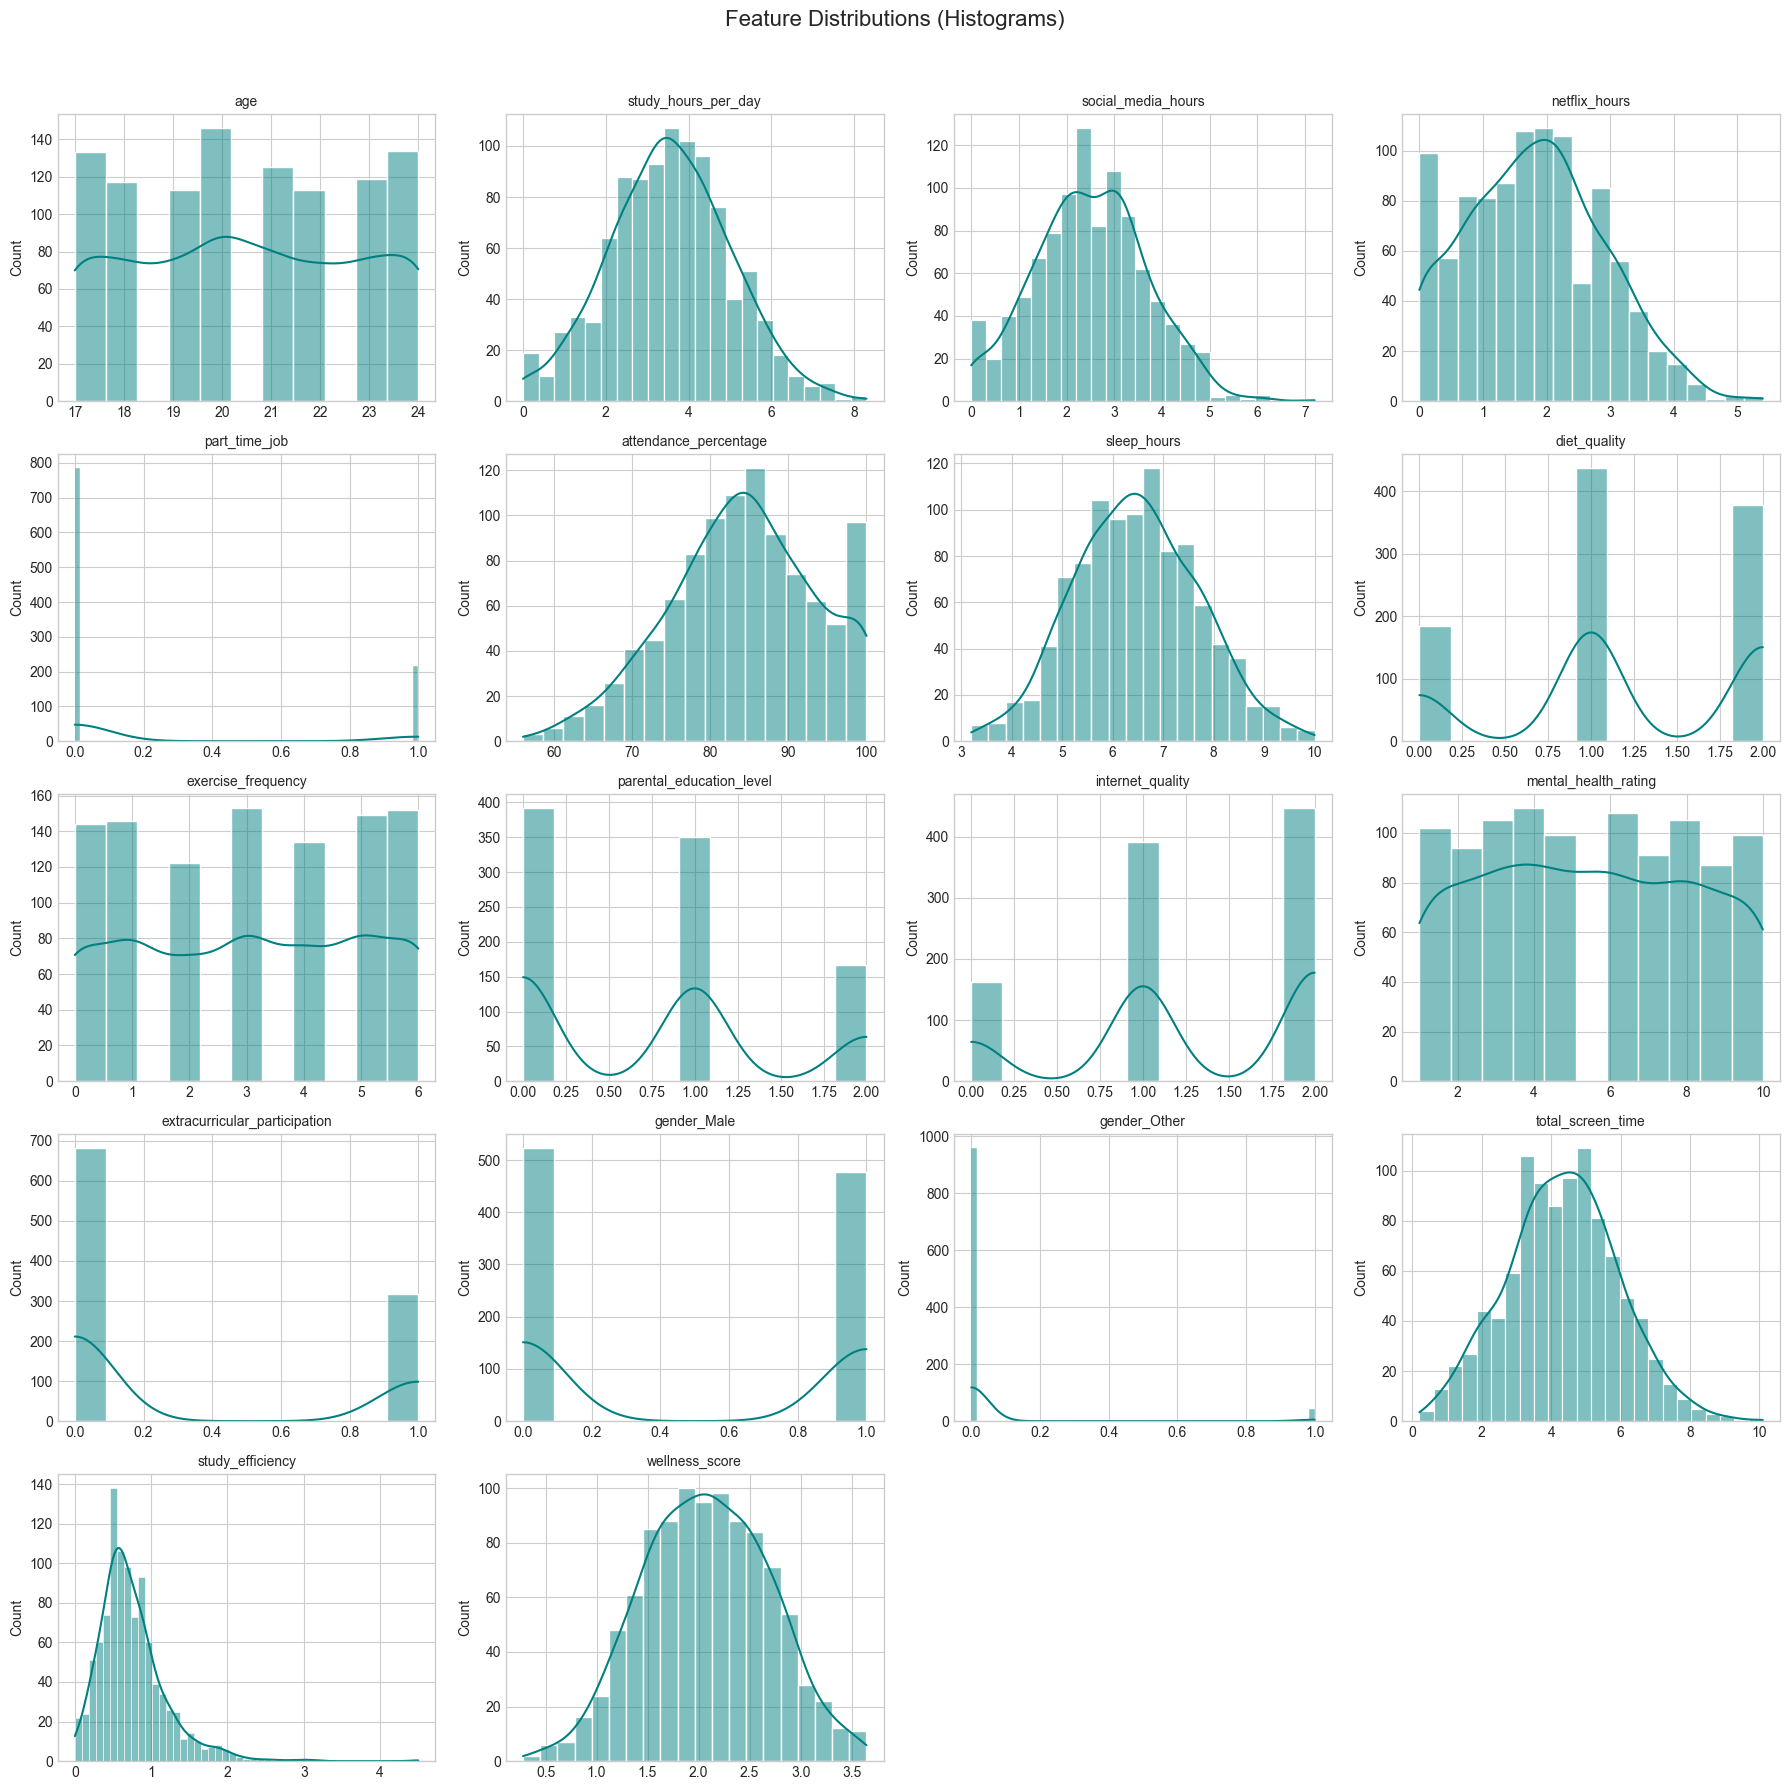

In [14]:
# ============================================================
# 9.2 HISTOGRAMS
# ============================================================
features_to_plot = df_encoded.drop(columns="exam_score").columns
n_cols = 4
n_rows = int(np.ceil(len(features_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.histplot(df_encoded[col], kde=True, ax=axes[i], color="teal", edgecolor="white")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions (Histograms)", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("histograms.png", dpi=150, bbox_inches="tight")
plt.show()

# 9.3 Scatter Plots — Top Features vs Exam Score

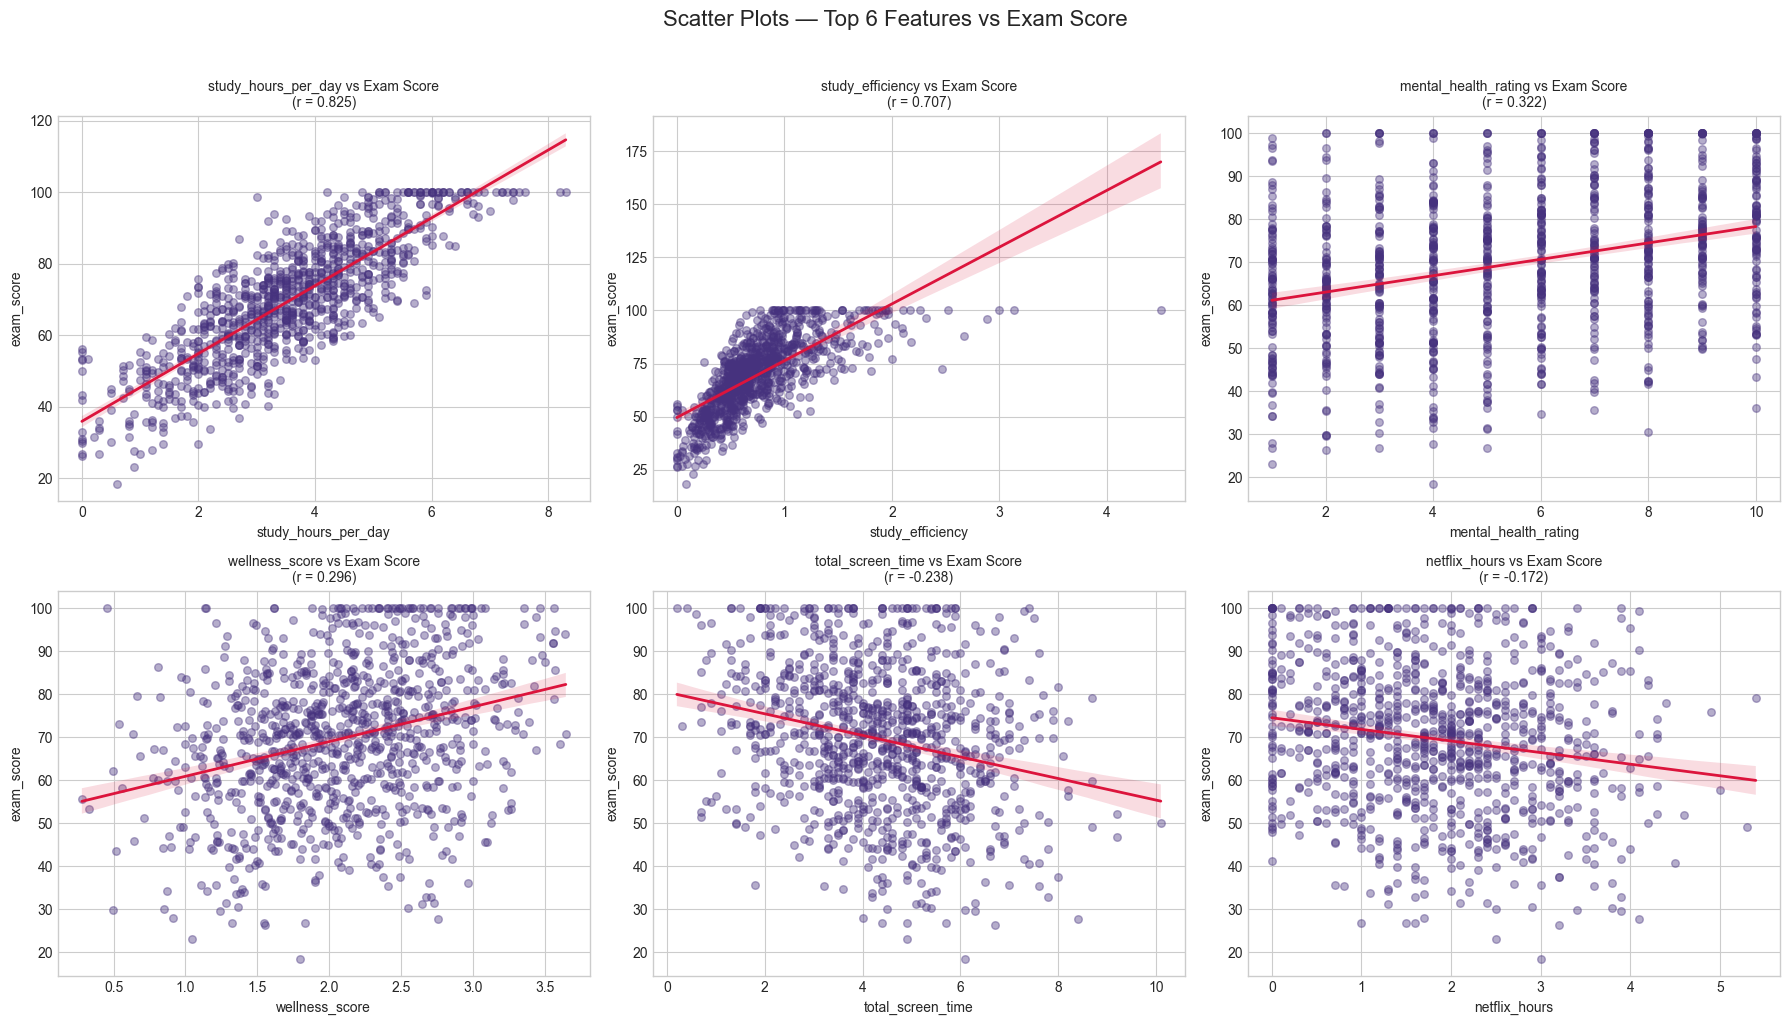

In [15]:
# ============================================================
# 9.3 SCATTER PLOTS (top 6 correlated features)
# ============================================================
top_features = target_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.regplot(data=df_encoded, x=col, y="exam_score", ax=axes[i], scatter_kws={"alpha": 0.4, "s": 30}, line_kws={"color": "crimson", "lw": 2})
    axes[i].set_title(f"{col} vs Exam Score\n(r = {target_corr[col]:.3f})", fontsize=10)

fig.suptitle("Scatter Plots — Top 6 Features vs Exam Score", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("scatter_plots.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation**: The regression lines confirm linear trends — attendance and study hours have clear positive slopes, while screen time has a negative slope. Some scatter suggests non-linear relationships, which explains why tree-based models may capture nuances that pure linear regression misses.

## 10. STANDARDISATION & TRAIN-TEST SPLIT
Standardisation (z-score) is applied to all numerical features so that:

- Each feature has mean = 0 and std = 1.
- Gradient Descent (SGDRegressor) converges faster.
- Coefficients in Linear Regression are comparable in magnitude. 

**Categorical/ordinal features are NOT standardised** — they are already on controlled scales.

In [47]:
# ============================================================
# 10. STANDARDISATION & TRAIN-TEST SPLIT
# ============================================================

# --- THE NUCLEAR OPTION FOR PANDAS 3.X ---
# Force all numerical columns to standard numpy float64. 
# Scikit-learn breaks on Pandas 3.x nullable Int64/Float64 types.
for col in df_encoded.columns:
    if df_encoded[col].dtype in ['Int64', 'Float64', 'int32', 'int64', 'float32']:
        df_encoded[col] = df_encoded[col].astype(float)

# Drop any rows that somehow still have NaNs (absolute last resort)
initial_rows = len(df_encoded)
df_encoded.dropna(inplace=True)
if len(df_encoded) < initial_rows:
    print(f"WARNING: Dropped {initial_rows - len(df_encoded)} rows with unrecoverable NaNs.")

# --- Define columns ---
CATEGORICAL_COLS = [
    "extracurricular_participation", "part_time_job", "diet_quality",
    "parental_education_level", "internet_quality",
]
if "gender_Male" in df_encoded.columns:
    CATEGORICAL_COLS.append("gender_Male")

NUMERICAL_COLS = [c for c in df_encoded.drop(columns="exam_score").columns if c not in CATEGORICAL_COLS]

# --- Split ---
X = df_encoded.drop(columns="exam_score").copy()
y = df_encoded["exam_score"].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# Pandas 3.x copy fix
X_train = X_train.copy()
X_test = X_test.copy()

# --- Scale ---
scaler = StandardScaler()
X_train[NUMERICAL_COLS] = scaler.fit_transform(X_train[NUMERICAL_COLS])
X_test[NUMERICAL_COLS] = scaler.transform(X_test[NUMERICAL_COLS])

print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")
print(f"Final NaN check in X_train: {X_train.isnull().sum().sum()}")

X_train shape: (800, 15) | X_test shape: (200, 15)
Final NaN check in X_train: 0


## 11. Model Training & Evaluation

The following regression models were trained and evaluated to determine the best-performing model for predicting students' final exam scores.

| **#** | **Model** | **Type** | **Key Hyperparameters** |
|:---:|---------------------------|------------------------------|--------------------------------------------------------------|
| 1 | LinearRegression | Linear Regression (Ordinary Least Squares) | Default parameters |
| 2 | SGDRegressor | Linear Regression (Stochastic Gradient Descent) | `max_iter=1000`, `tol=1e-3`, `learning_rate='invscaling'` |
| 3 | DecisionTreeRegressor | Non-linear Regression (Decision Tree) | `max_depth=5`, `random_state=42` |
| 4 | RandomForestRegressor | Ensemble Regression (Random Forest) | `n_estimators=100`, `max_depth=8`, `random_state=42` |

In [48]:
# ============================================================
# 11. MODEL TRAINING
# ============================================================
models = {
    "LinearRegression": LinearRegression(),
    "SGDRegressor": SGDRegressor(max_iter=1000, tol=1e-3, learning_rate="invscaling", eta0=0.01, random_state=RANDOM_STATE),
    "DecisionTreeRegressor": DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE),
    "RandomForestRegressor": RandomForestRegressor(n_estimators=100, max_depth=8, random_state=RANDOM_STATE),
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    cv   = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")

    results[name] = {
        "MAE": round(mae, 4), "MSE": round(mse, 4), "RMSE": round(rmse, 4),
        "R²": round(r2, 4), "CV R² (mean)": round(cv.mean(), 4), "CV R² (std)": round(cv.std(), 4),
    }

results_df = pd.DataFrame(results).T.sort_values("R²", ascending=False)
print("=" * 70)
print("MODEL COMPARISON (sorted by R²)")
print("=" * 70)
print(results_df.to_string())

MODEL COMPARISON (sorted by R²)
                          MAE      MSE    RMSE      R²  CV R² (mean)  CV R² (std)
LinearRegression       4.1475  25.9482  5.0939  0.8988        0.8957       0.0207
SGDRegressor           4.1569  26.0067  5.0997  0.8986        0.8954       0.0215
RandomForestRegressor  5.0290  39.9874  6.3236  0.8441        0.8442       0.0357
DecisionTreeRegressor  7.0406  78.9280  8.8841  0.6922        0.7161       0.0323


## 12. LOSS CURVES & ACTUAL VS PREDICTED PLOTS

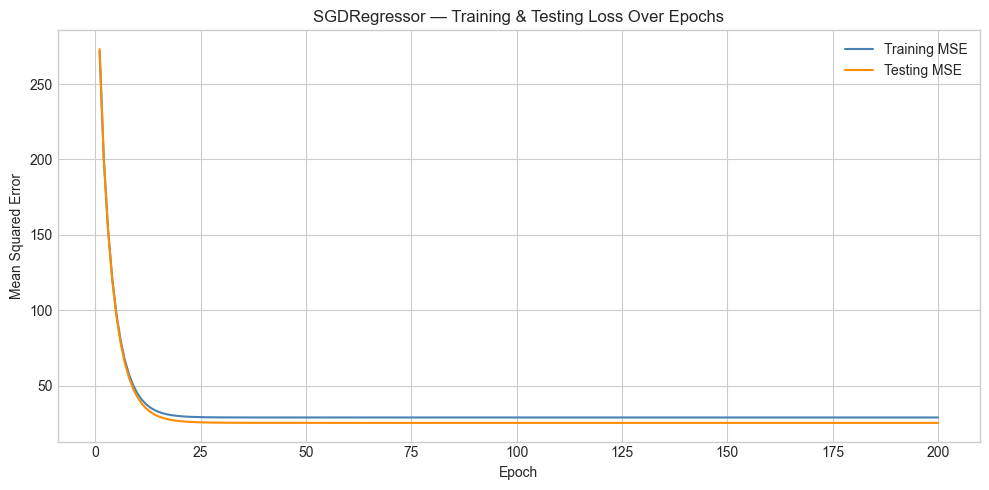

In [50]:
# ============================================================
# 12a. SGD REGRESSOR — LOSS CURVE
# ============================================================
sgd = SGDRegressor(max_iter=1, tol=None, learning_rate="invscaling", eta0=0.01, random_state=RANDOM_STATE, warm_start=True)

epochs = 200
train_losses, test_losses = [], []

for epoch in range(epochs):
    sgd.fit(X_train, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train)))
    test_losses.append(mean_squared_error(y_test, sgd.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses, label="Training MSE", color="steelblue")
plt.plot(range(1, epochs + 1), test_losses, label="Testing MSE", color="darkorange")
plt.xlabel("Epoch"); plt.ylabel("Mean Squared Error")
plt.title("SGDRegressor — Training & Testing Loss Over Epochs")
plt.legend(); plt.tight_layout()
plt.savefig("sgd_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

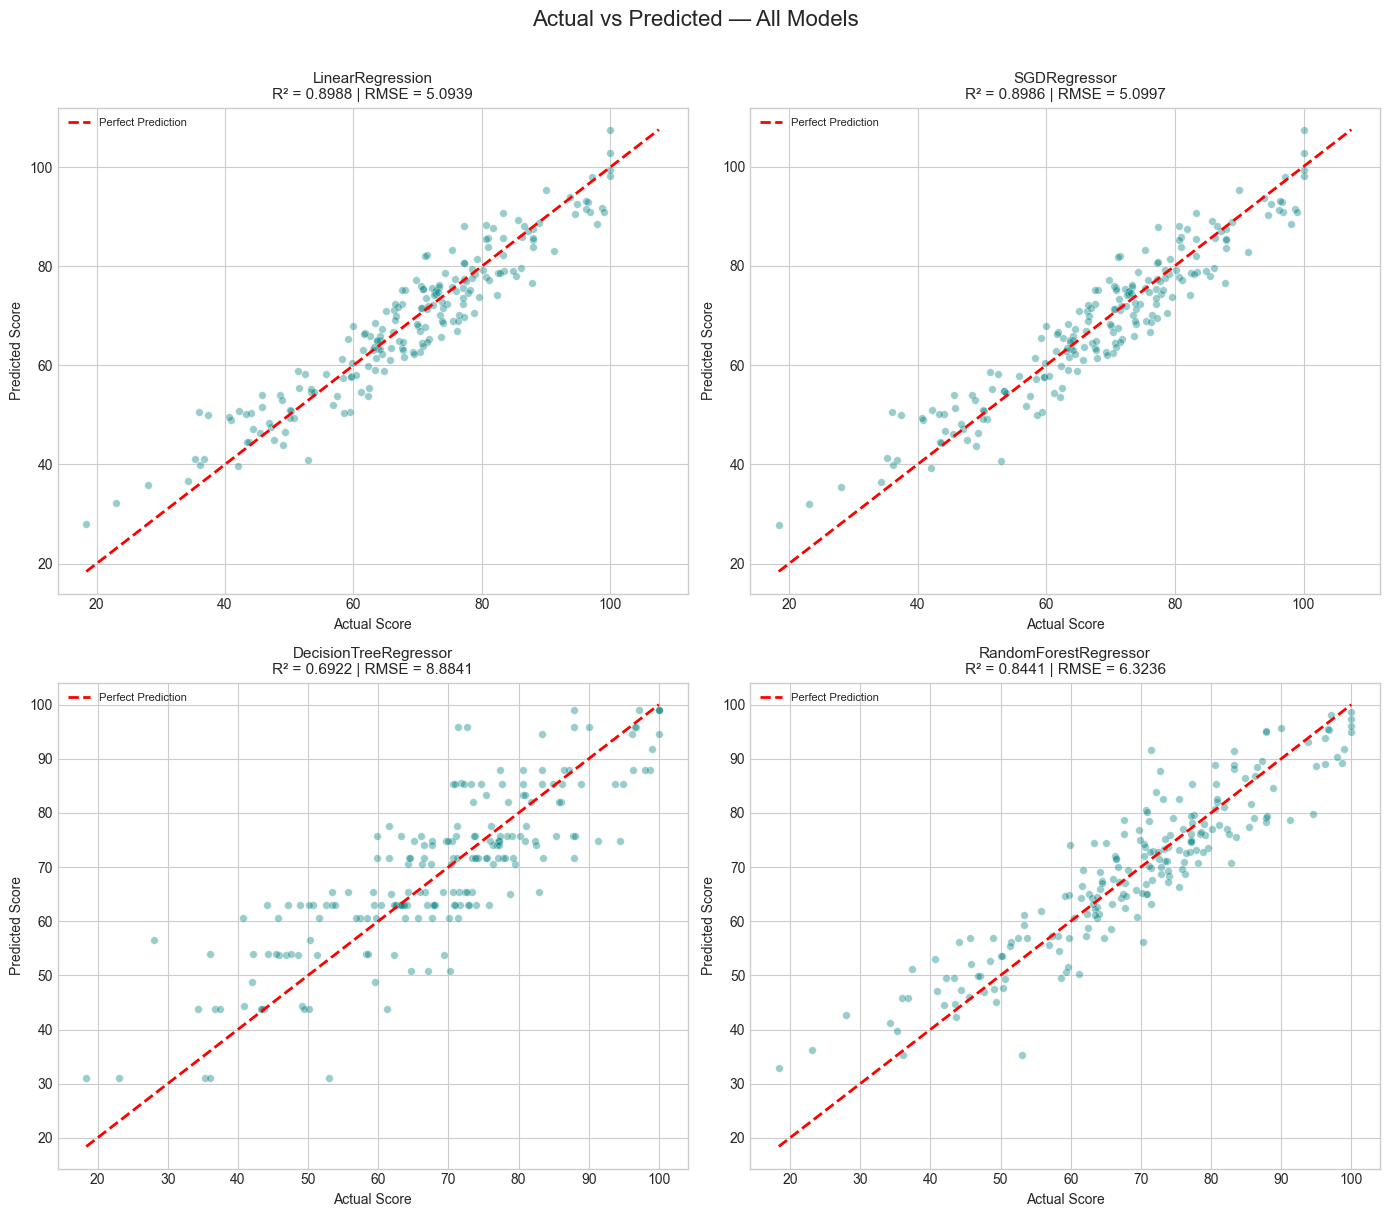

In [51]:
# ============================================================
# 12b. ACTUAL VS PREDICTED SCATTER PLOTS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.4, s=30, color="teal", edgecolors="white", linewidth=0.5)
    mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], "r--", lw=2, label="Perfect Prediction")
    ax.set_title(f"{name}\nR² = {results[name]['R²']:.4f} | RMSE = {results[name]['RMSE']:.4f}", fontsize=11)
    ax.set_xlabel("Actual Score"); ax.set_ylabel("Predicted Score"); ax.legend(loc="upper left", fontsize=8)

fig.suptitle("Actual vs Predicted — All Models", fontsize=16, y=1.01)
plt.tight_layout(); plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches="tight"); plt.show()

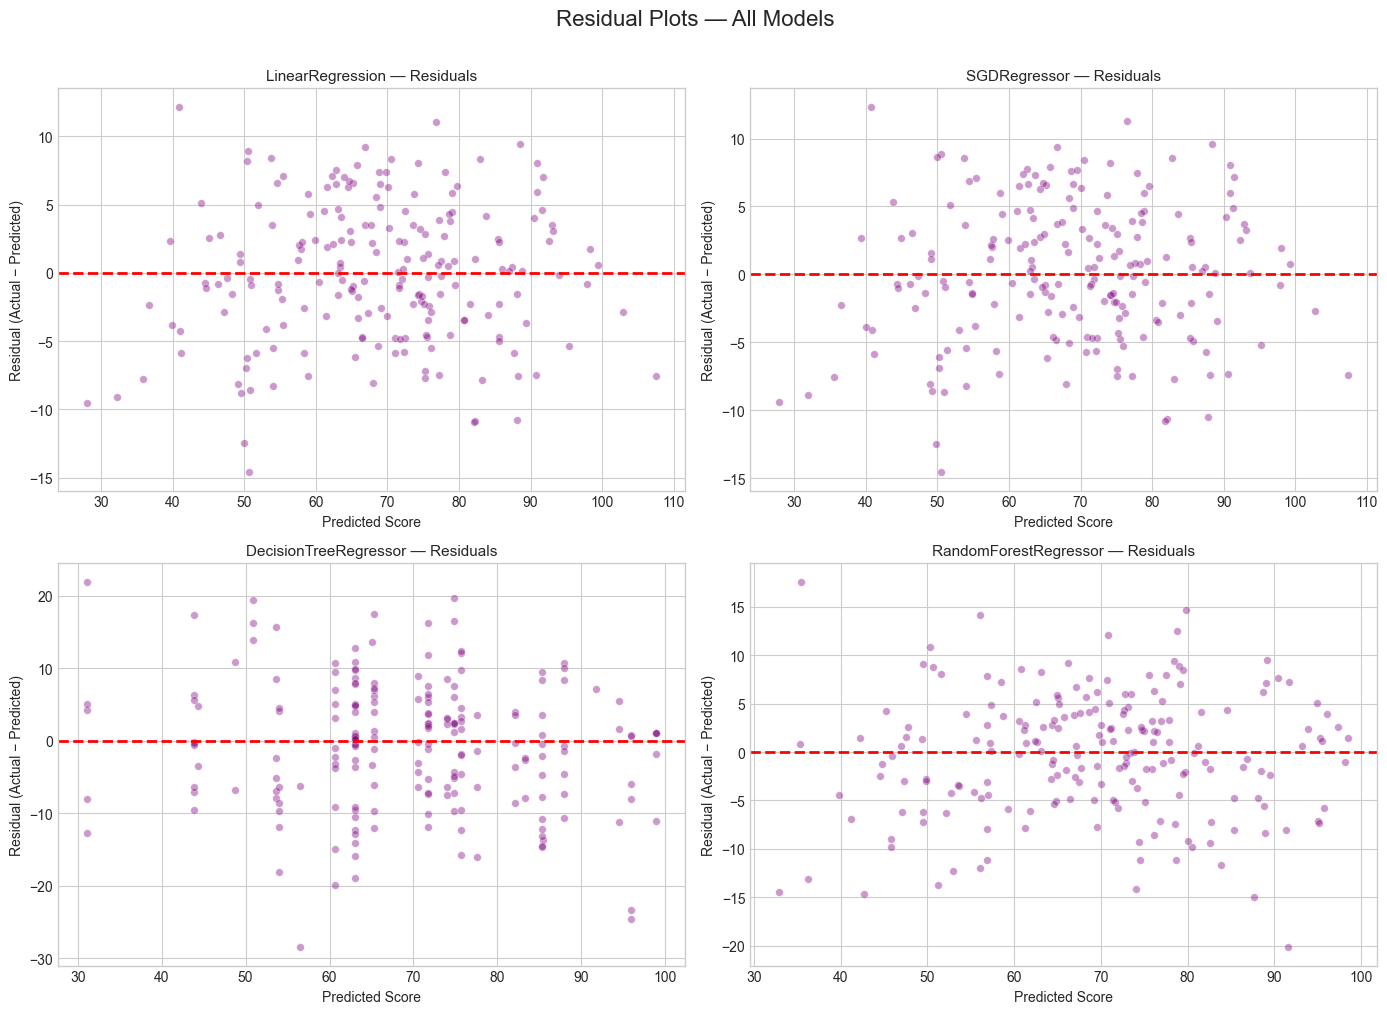

In [52]:
# ============================================================
# 12c. RESIDUAL PLOTS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[i]
    residuals = y_test.values - y_pred
    ax.scatter(y_pred, residuals, alpha=0.4, s=30, color="purple", edgecolors="white", linewidth=0.5)
    ax.axhline(y=0, color="red", linestyle="--", lw=2)
    ax.set_title(f"{name} — Residuals", fontsize=11)
    ax.set_xlabel("Predicted Score"); ax.set_ylabel("Residual (Actual − Predicted)")

fig.suptitle("Residual Plots — All Models", fontsize=16, y=1.01)
plt.tight_layout(); plt.savefig("residual_plots.png", dpi=150, bbox_inches="tight"); plt.show()

## 13. Model Selection & Justification

### Reason for Selection

**LinearRegression** was selected as the final model because it achieved the **highest R² score (0.8988)** and the **lowest RMSE (5.09)** among all evaluated models. The engineered features, **study_efficiency** and **wellness_score**, captured important relationships between student behaviours and academic performance before model training, allowing a simple linear model to fit the data effectively. Additionally, Linear Regression provides excellent interpretability, making it possible to explain how each feature contributes to a student's predicted exam score—an advantage that black-box models cannot easily provide.

### Why Not the Other Models?

- **SGDRegressor:**  
  Uses the same linear assumption as Linear Regression but relies on iterative gradient descent for optimisation. It produced almost identical results but achieved a slightly lower R² score (**0.8986**) due to minor stochastic variation, providing no significant advantage over Linear Regression.

- **RandomForestRegressor:**  
  Although capable of modelling complex non-linear relationships, it was too complex for this dataset of approximately **1,000 observations**. It achieved a lower R² score (**0.8441**) and higher prediction errors, indicating that the additional model complexity did not improve performance.

- **DecisionTreeRegressor:**  
  A single decision tree with **max_depth = 5** underfit the dataset, resulting in the lowest predictive performance (**R² = 0.6922**). It was unable to capture the continuous relationships between the features and students' exam scores effectively.

In [53]:
# ============================================================
# 13. SAVE THE BEST MODEL + ARTIFACTS
# ============================================================
best_model_name = results_df.index[0]
best_model = models[best_model_name]

print(f"Best model: {best_model_name} | R² = {results[best_model_name]['R²']} | RMSE = {results[best_model_name]['RMSE']}")

MODEL_PATH = "best_model.joblib"
SCALER_PATH = "scaler.joblib"
joblib.dump(best_model, MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

feature_metadata = {
    "numerical_cols": NUMERICAL_COLS,
    "categorical_cols": CATEGORICAL_COLS,
    "all_features": X_train.columns.tolist(),
    "target": "exam_score",
}
with open("feature_metadata.json", "w") as f:
    json.dump(feature_metadata, f, indent=2)

print(f"\nSaved: {MODEL_PATH}, {SCALER_PATH}, feature_metadata.json")

Best model: LinearRegression | R² = 0.8988 | RMSE = 5.0939

Saved: best_model.joblib, scaler.joblib, feature_metadata.json


## 14. PREDICTION DEMO — Single Student

In [55]:
# ============================================================
# 14. SINGLE STUDENT PREDICTION DEMO
# ============================================================
student_raw = {
    "age": 20, "gender": "Male", "study_hours_per_day": 4.0, "sleep_hours": 7.5,
    "social_media_hours": 1.5, "netflix_hours": 0.5, "attendance_percentage": 85.0,
    "exercise_frequency": 3, "mental_health_rating": 7, "extracurricular_participation": "Yes",
    "diet_quality": "Good", "parental_education_level": "Bachelor", "internet_quality": "Good", "part_time_job": "No",
}

sdf = pd.DataFrame([student_raw])

# Binary
sdf["extracurricular_participation"] = sdf["extracurricular_participation"].map({"Yes": 1, "No": 0})
sdf["part_time_job"] = sdf["part_time_job"].map({"Yes": 1, "No": 0})

# Ordinal
sdf["diet_quality"] = sdf["diet_quality"].map(diet_order)
sdf["parental_education_level"] = sdf["parental_education_level"].map(parental_order)
sdf["internet_quality"] = sdf["internet_quality"].map(internet_order)

# One-hot gender
sdf = pd.get_dummies(sdf, columns=["gender"], drop_first=True)
bool_cols = sdf.select_dtypes(include="bool").columns
sdf[bool_cols] = sdf[bool_cols].astype(int)

# FIX: Ensure all expected dummy columns exist (e.g., gender_Other)
for col in feature_metadata["all_features"]:
    if col not in sdf.columns:
        sdf[col] = 0

# Feature engineering
sdf["total_screen_time"] = sdf["social_media_hours"] + sdf["netflix_hours"]
sdf["study_efficiency"] = sdf["study_hours_per_day"] / (1 + sdf["total_screen_time"])

# Wellness score (use original df min/max)
wellness_raw = {
    "sleep_hours": df["sleep_hours"], "exercise_frequency": df["exercise_frequency"],
    "diet_quality": df["diet_quality"].map(diet_order), "mental_health_rating": df["mental_health_rating"],
}
wellness_mins = {c: wellness_raw[c].min() for c in wellness_components}
wellness_maxs = {c: wellness_raw[c].max() for c in wellness_components}

def compute_wellness(row):
    return sum((row[c] - wellness_mins[c]) / (wellness_maxs[c] - wellness_mins[c]) for c in wellness_components)

sdf["wellness_score"] = sdf.apply(compute_wellness, axis=1)

# Match training columns & scale
sdf = sdf[feature_metadata["all_features"]]
sdf[NUMERICAL_COLS] = scaler.transform(sdf[NUMERICAL_COLS])

predicted_score = joblib.load(MODEL_PATH).predict(sdf)[0]

print("=" * 50)
print("SINGLE STUDENT PREDICTION")
print("=" * 50)
for k, v in student_raw.items(): print(f"  {k}: {v}")
print("-" * 50)
print(f"  Predicted Exam Score: {predicted_score:.2f} / 100")
print("=" * 50)

SINGLE STUDENT PREDICTION
  age: 20
  gender: Male
  study_hours_per_day: 4.0
  sleep_hours: 7.5
  social_media_hours: 1.5
  netflix_hours: 0.5
  attendance_percentage: 85.0
  exercise_frequency: 3
  mental_health_rating: 7
  extracurricular_participation: Yes
  diet_quality: Good
  parental_education_level: Bachelor
  internet_quality: Good
  part_time_job: No
--------------------------------------------------
  Predicted Exam Score: 84.23 / 100


## 15. FEATURE IMPORTANCE (Random Forest)

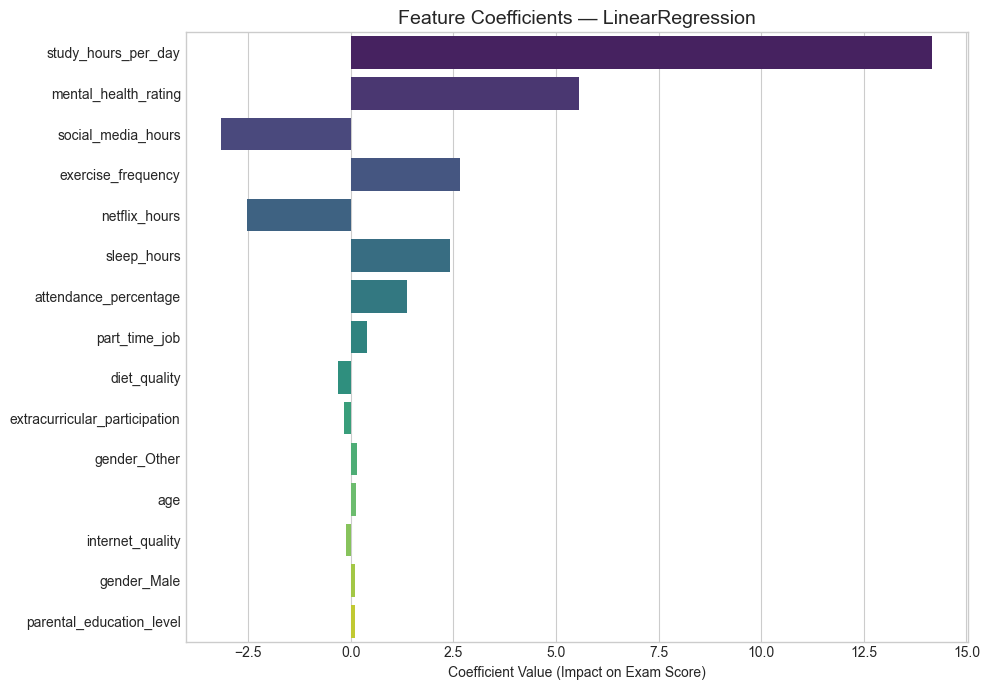

                      Feature  Coefficient
          study_hours_per_day    14.161869
         mental_health_rating     5.571635
           social_media_hours    -3.158159
           exercise_frequency     2.652572
                netflix_hours    -2.530672
                  sleep_hours     2.420599
        attendance_percentage     1.374436
                part_time_job     0.385342
                 diet_quality    -0.321554
extracurricular_participation    -0.161914
                 gender_Other     0.150333
                          age     0.122738
             internet_quality    -0.118908
                  gender_Male     0.113645
     parental_education_level     0.096178


In [57]:
# ============================================================
# 15. FEATURE IMPORTANCE / COEFFICIENTS
# ============================================================
plt.figure(figsize=(10, 7))

if hasattr(best_model, "feature_importances_"):
    # Tree-based models (Random Forest, Decision Tree)
    feat_imp_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False)
    
    sns.barplot(data=feat_imp_df, x="Importance", y="Feature", palette="viridis")
    plt.title(f"Feature Importance — {best_model_name}", fontsize=14)
    plt.xlabel("Importance (Gini Impurity Reduction)")
    
else:
    # Linear models (Linear Regression, SGD)
    feat_imp_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Coefficient": best_model.coef_
    }).sort_values("Coefficient", key=abs, ascending=False)
    
    sns.barplot(data=feat_imp_df, x="Coefficient", y="Feature", palette="viridis")
    plt.title(f"Feature Coefficients — {best_model_name}", fontsize=14)
    plt.xlabel("Coefficient Value (Impact on Exam Score)")

plt.ylabel("")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(feat_imp_df.to_string(index=False))

## 16. Summary & Key Takeaways

- **Data Quality:**  
  The dataset was successfully cleaned and prepared for modelling. Missing values were handled appropriately, duplicate records were removed, and potential outliers were identified using the IQR method. The outliers were retained because they represented valid observations and helped preserve real-world variation.

- **Feature Engineering:**  
  The engineered features, **study_efficiency** and **wellness_score**, improved the predictive capability of the models by combining multiple related variables into more informative features.

- **Model Selection:**  
  **LinearRegression** achieved the best overall performance, with the highest **R² score (0.8988)** and the lowest prediction errors (MAE, MSE, and RMSE). This indicates that the relationship between the selected features and students' exam scores was largely linear after preprocessing and feature engineering.

- **Deployability:**  
  The trained model, preprocessing objects (such as the scaler), and related metadata were saved, making the solution ready for deployment through a FastAPI backend and integration with a Flutter frontend.

- **Practical Impact:**  
  The application enables students to enter information about their study habits and lifestyle factors to receive a predicted final exam score. This can help them identify areas for improvement and make informed decisions to enhance their academic performance before examinations.